# Pair Trading - Statistical Arbitrage

## Data Fetch

In [83]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [84]:
start_date = "2023-01-15"
end_date = '2026-03-12'
tick_wti = 'CL=F'
tick_brent = 'BZ=F'

In [85]:
df_wti = yf.download(tickers=tick_wti, start=start_date, end=end_date).interpolate(method='linear')
df_brent = yf.download(tickers=tick_brent, start=start_date, end=end_date).interpolate(method='linear')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [86]:
df_wti.head()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2023-01-17,80.180000,81.230003,78.529999,80.099998,312275
2023-01-18,79.480003,82.379997,78.940002,80.970001,92549
2023-01-19,80.330002,81.180000,78.129997,79.139999,58863
2023-01-20,81.309998,81.639999,79.690002,80.599998,300145
2023-01-23,81.620003,82.639999,81.050003,81.790001,297076


In [87]:
df_brent.head()

Price,Close,High,Low,Open,Volume
Ticker,BZ=F,BZ=F,BZ=F,BZ=F,BZ=F
Date,,,,,
2023-01-17,85.919998,86.820000,83.860001,85.440002,36658
2023-01-18,84.980003,87.839996,84.400002,86.720001,26461
2023-01-19,86.160004,86.849998,83.739998,84.589996,28822
2023-01-20,87.629997,87.769997,85.580002,86.360001,24374
2023-01-23,88.190002,89.099998,86.930000,87.809998,21194


Text(0.5, 1.0, 'WTI Crude Prices')

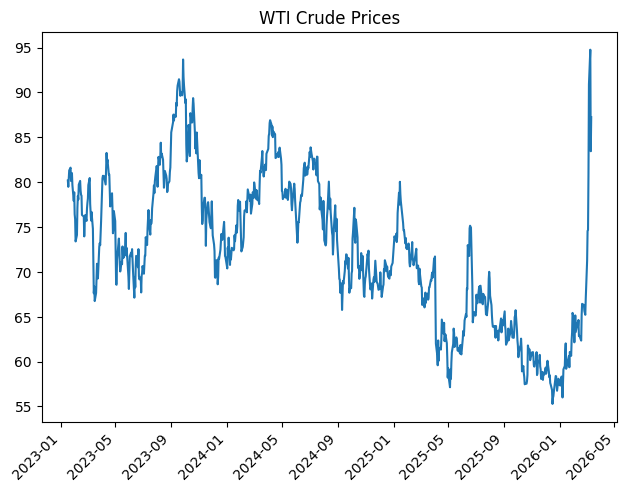

In [88]:
fig, ax = plt.subplots()
ax.plot(df_wti.Close)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.autofmt_xdate
ax.set_title('WTI Crude Prices')

Text(0.5, 1.0, 'Brent Crude Prices')

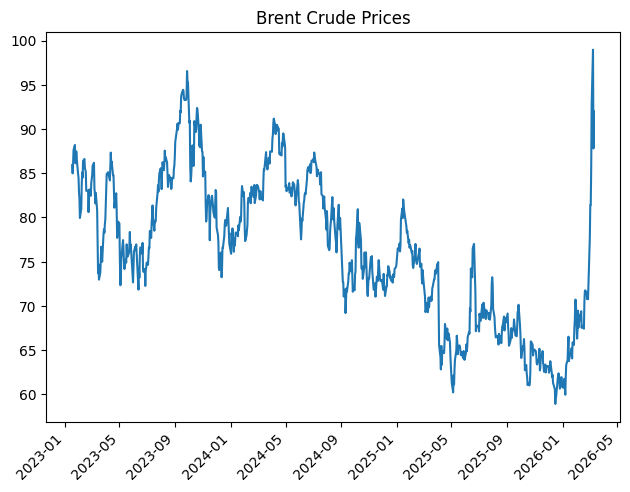

In [89]:
fig, ax = plt.subplots()
ax.plot(df_brent.Close)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.autofmt_xdate
ax.set_title('Brent Crude Prices')

In [90]:

for i in range(len(x_w)):
    if df_wti.index[i] != df_brent.index[i]:
        print(df_wti.index[i])
print(len(x_w), len(x_b))

2023-11-24 00:00:00
2023-11-27 00:00:00
2023-11-28 00:00:00
2023-11-29 00:00:00
2023-11-30 00:00:00
2023-12-01 00:00:00
2023-12-04 00:00:00
2023-12-05 00:00:00
2023-12-06 00:00:00
2023-12-07 00:00:00
2023-12-08 00:00:00
2023-12-11 00:00:00
2023-12-12 00:00:00
2023-12-13 00:00:00
2023-12-14 00:00:00
2023-12-15 00:00:00
2023-12-18 00:00:00
2023-12-19 00:00:00
2023-12-20 00:00:00
2023-12-21 00:00:00
2023-12-22 00:00:00
2023-12-26 00:00:00
2023-12-27 00:00:00
2023-12-28 00:00:00
2023-12-29 00:00:00
2024-01-02 00:00:00
2024-01-03 00:00:00
2024-01-04 00:00:00
2024-01-05 00:00:00
2024-01-08 00:00:00
2024-01-09 00:00:00
2024-01-10 00:00:00
2024-01-11 00:00:00
2024-01-12 00:00:00
2024-01-16 00:00:00
2024-01-17 00:00:00
2024-01-18 00:00:00
2024-01-19 00:00:00
2024-01-22 00:00:00
2024-01-23 00:00:00
2024-01-24 00:00:00
2024-01-25 00:00:00
2024-01-26 00:00:00
2024-01-29 00:00:00
2024-01-30 00:00:00
2024-01-31 00:00:00
2024-02-01 00:00:00
2024-02-02 00:00:00
2024-02-05 00:00:00
2024-02-06 00:00:00


In [91]:
wti_dates = set(df_wti.index)
brent_dates = set(df_brent.index)

only_in_wti = sorted(wti_dates - brent_dates)
only_in_brent = sorted(brent_dates - wti_dates)

print("Only in WTI:", only_in_wti[:20])
print("Count only in WTI:", len(only_in_wti))

print("Only in Brent:", only_in_brent[:20])
print("Count only in Brent:", len(only_in_brent))

Only in WTI: []
Count only in WTI: 0
Only in Brent: [Timestamp('2023-11-23 00:00:00')]
Count only in Brent: 1


In [94]:
common_dates = df_wti.index.intersection(df_brent.index)

df_wti = df_wti.loc[common_dates].sort_index()
df_brent = df_brent.loc[common_dates].sort_index()

print(len(df_wti), len(df_brent))
print((df_wti.index == df_brent.index).all())

x_w = df_wti.Close
x_b = df_brent.Close

792 792
True


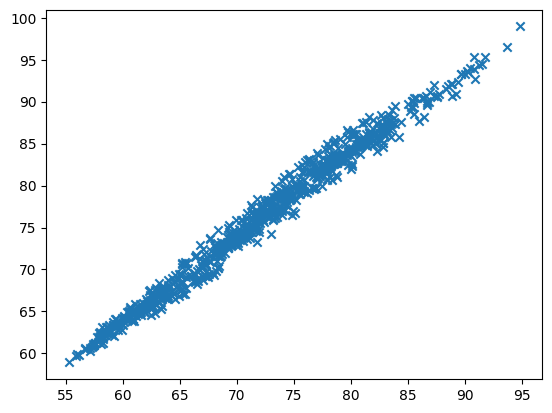

In [96]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS



plt.scatter(x_w, x_b, marker='x')

In [ ]:
from statsmodels.api import add_constant
X = add_constant(x_w) 
model = OLS(x_b, X)
model_fit = model.fit()
model_fit.summary()

params = 



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   BZ=F   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                 4.991e+04
Date:                Thu, 26 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:31:10   Log-Likelihood:                -1155.8
No. Observations:                 792   AIC:                             2316.
Df Residuals:                     790   BIC:                             2325.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8837      0.331      8.723      0.000       2.235       3.533
CL=F           1.0160      0.005    223.404      0.000       1.007       1.025
==============================================================================
Omnibus:                       13.076   Durbin-Watson:                   0.150
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               15.051
Skew:                           0.233   Prob(JB):                     0.000539
Kurtosis:                       3.489   Cond. No.                         649.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""